In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [7]:
df = df.iloc[:,1:] # row,column

In [8]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


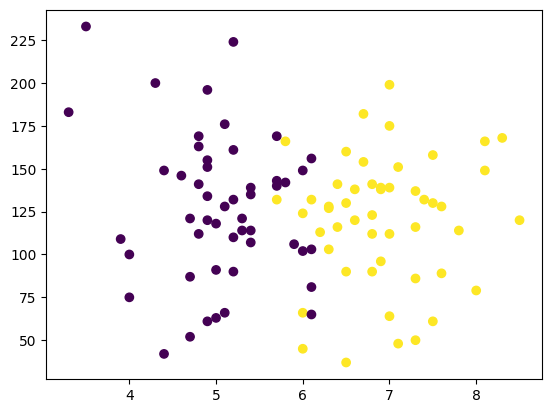

In [14]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [15]:
X = df.iloc[:,0:2]

In [16]:
Y = df.iloc[:,-1]

In [18]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [19]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1)

In [23]:
X_test

,cgpa,iq
84,5.7,169.0
16,5.2,224.0
43,6.8,141.0
69,8.5,120.0
8,6.1,156.0
89,4.9,151.0
57,6.5,130.0
39,4.6,146.0
1,5.9,106.0
47,5.2,161.0


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train)

In [28]:
X_train

array([[-1.48308286,  2.00857451],
       [ 0.00291372,  0.08600949],
       [ 0.00291372,  0.71843219],
       [ 0.26514841,  0.18719712],
       [ 1.13926404, -1.78596171],
       [-2.18237536,  2.84337247],
       [-0.17190941,  1.14847963],
       [-0.60896722,  0.01011876],
       [ 1.83855655,  1.14847963],
       [ 0.26514841, -0.44522558],
       [ 1.31408717,  0.23779094],
       [ 0.17773685, -0.1922565 ],
       [-0.52155566, -0.16695959],
       [ 1.13926404, -0.87527302],
       [ 2.01337967,  1.19907345],
       [ 1.13926404,  0.41486929],
       [ 1.57632186, -0.16695959],
       [-2.35719849,  1.57852707],
       [-1.83272911, -0.29344413],
       [-1.74531755, -1.15353901],
       [-0.52155566, -0.34403795],
       [ 0.00291372, -0.47052249],
       [ 0.61479466,  0.84491673],
       [-1.04602504,  0.51605693],
       [-0.78379035,  0.18719712],
       [-1.1334366 , -0.84997611],
       [-0.87120191, -0.06577196],
       [ 0.87702935,  0.46546311],
       [ 0.61479466,

In [30]:
X_test = scaler.transform(X_test)

In [31]:
X_test

array([[-0.25932097,  1.22437035],
       [-0.69637879,  2.6157003 ],
       [ 0.70220623,  0.51605693],
       [ 2.1882028 , -0.01517814],
       [ 0.09032528,  0.89551055],
       [-0.95861348,  0.76902601],
       [ 0.43997154,  0.23779094],
       [-1.22084817,  0.64254147],
       [-0.08449784, -0.36933486],
       [-0.69637879,  1.02199509]])

In [32]:
from sklearn.linear_model import LogisticRegression

In [34]:
clf = LogisticRegression()

In [35]:
clf.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
y_predict = clf.predict(X_test)

In [37]:
y_predict

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 0])

In [39]:
Y_test

84    0
16    0
43    1
69    1
8     0
89    0
57    1
39    0
1     0
47    0
Name: placement, dtype: int64

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
accuracy_score(Y_test,y_predict)

0.9

In [44]:
pip install  mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 17.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [46]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

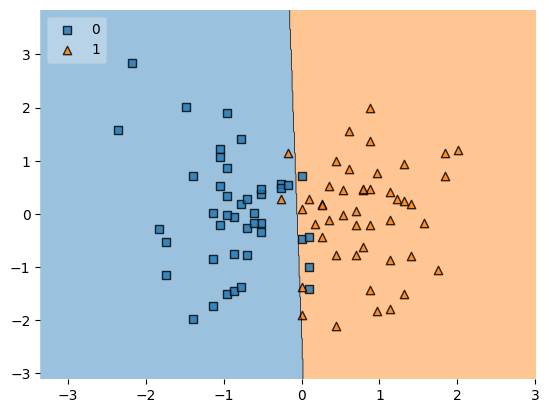

In [53]:
plot_decision_regions(X_train,Y_train.values,clf=clf ,legend=2)

In [55]:
import pickle

In [57]:
pickle.dump(clf,open('model.pkl','wb')) #wb = write_binary